##Set up workspace
Clone the project repo into Colab and move into the folder so all the relative paths work

In [73]:

import os, sys, subprocess

REPO_URL  = "https://github.com/Baasmaala/road-safety-explorer.git"
REPO_NAME = "road-safety-explorer"
BRANCH    = "basmala"

# Clone if not already cloned, otherwise pull latest
if not os.path.exists(REPO_NAME):
    print(f"Cloning {REPO_NAME}...")
    subprocess.run(["git", "clone", "-b", BRANCH, REPO_URL], check=True)
else:
    print(f"Repo already cloned — pulling latest from {BRANCH}...")
    subprocess.run(["git", "-C", REPO_NAME, "fetch", "origin"], check=True)
    subprocess.run(["git", "-C", REPO_NAME, "checkout", BRANCH], check=True)
    subprocess.run(["git", "-C", REPO_NAME, "pull", "origin", BRANCH], check=True)

# Move into the repo so all paths like data/raw/... just work
os.chdir(REPO_NAME)
print(f"\n Working directory: {os.getcwd()}")
print(f" On branch: {BRANCH}")
print(f" Files available:")
subprocess.run(["ls", "-la", "data/raw/"])

Cloning road-safety-explorer...

 Working directory: /content/road-safety-explorer/road-safety-explorer/road-safety-explorer
 On branch: basmala
 Files available:


CompletedProcess(args=['ls', '-la', 'data/raw/'], returncode=0)

# Road Safety - Data Cleaning and Clustering

This notebook cleans the WHO Global Status Report on Road Safety 2023 dataset and runs K-Means clustering on it. The cleaning logic is wrapped in a reusable function near the end so the Streamlit app can use the same pipeline when a user uploads their own country-level dataset.

The cleaned outputs are saved to `data/processed/` for the other two notebooks (PCA + Anomaly Detection, Time Series Forecasting) and the final app to use.

### Imports

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy import stats

sns.set_style('whitegrid')

### Load the file

The Excel file has two header rows. The first row contains short codes like CP_0, CP_1, and the second row has the actual column names we want to use. We tell pandas to use row index 1 as the header, then drop the leftover code row that ends up at the top of the data.

In [75]:
RAW_PATH = 'data/raw/gsrrs23-indicators-for-participating-countries-or-territories.xlsx'

df = pd.read_excel(RAW_PATH, sheet_name='Indicators', header=1)
df = df.iloc[1:].reset_index(drop=True)

df.shape

(171, 228)

In [76]:
df.head(3)

,WHO status,ISO_3 country name,Country name,Population,Income group,WHO Region,GRSSR participation 2009,GRSSR participation 2013,GRSSR participation 2015,GRSSR participation 2018,...,Year WHO-estimated road traffic fatalities (Update),2010 WHO-estimated road traffic fatalities (update),2010 Lower bound WHO-estimated road traffic fatalities (update),2010 Upper bound WHO-estimated road traffic fatalities (update),2010 WHO-estimated rate per 100 000 population (update),Year WHO-estimated road traffic fatalities (Update).1,2016 WHO-estimated road traffic fatalities (update),2016 Lower bound WHO-estimated road traffic fatalities (update),2016 Upper bound WHO-estimated road traffic fatalities (update),2016 WHO-estimated rate per 100 000 population (update)
0,Member State,ALB,Albania,2854710,Upper middle income,European Region,2009.0,2013.0,2015.0,2018.0,...,2010,388.0,364.0,412.0,13.3,2016,370.0,344.0,395.0,12.8
1,Member State,DZA,Algeria,44177969,Lower middle income,African Region,NaN,NaN,2015.0,NaN,...,2010,8039.0,7231.0,8848.0,22.4,2016,8536.0,7558.0,9514.0,21.2
2,Member State,ATG,Antigua and Barbuda,93219,High income,Region of the Americas,NaN,NaN,2015.0,2018.0,...,2010,5.0,5.0,5.0,5.8,2016,8.0,7.0,9.0,8.8


### What am I doing here and why

Before touching the data I want to understand what is actually inside it. The summary table below lists every column, its data type, how many values are filled in, how many are missing, and what percent that missing share is. This tells me which columns are clean enough to use directly and which ones I will have to drop or fill in later.

I am also pulling out just the label columns separately so I can confirm that every row really is one country, with proper identification (ISO code, name, region, income group).

In [77]:
summary = pd.DataFrame({
    'dtype': df.dtypes,
    'non_null': df.notna().sum(),
    'missing': df.isna().sum(),
    'missing_%': (df.isna().mean() * 100).round(1)
})
summary.head(20)

,dtype,non_null,missing,missing_%
WHO status,object,171,0,0.0
ISO_3 country name,object,171,0,0.0
Country name,object,171,0,0.0
Population,int64,171,0,0.0
Income group,object,168,3,1.8
WHO Region,object,171,0,0.0
GRSSR participation 2009,float64,159,12,7.0
GRSSR participation 2013,float64,163,8,4.7
GRSSR participation 2015,float64,163,8,4.7
GRSSR participation 2018,float64,161,10,5.8


The data has 171 countries and 228 columns. The first columns are basic info: country name, ISO code, population, income group, and WHO region. These are almost all filled in - only Income group has 3 missing values.

Next come the GRSSR participation columns. These show if a country joined the WHO road safety report in 2009, 2013, 2015, and 2018. Most countries joined, so only 5-7 percent are missing.

After that come the real road safety indicators. Total reported fatalities is almost complete, but when we look at the details - deaths by gender, deaths by road user type like pedestrian or cyclist - the missing values jump to 12-22 percent. This makes sense because not every country tracks deaths in that much detail.

The pattern is clear: simple info is filled in, but the more detailed a column gets, the more countries leave it empty. We will handle this in the missing values step below.

In [78]:
df[['ISO_3 country name', 'Country name', 'Population', 'Income group', 'WHO Region']].head()

,ISO_3 country name,Country name,Population,Income group,WHO Region
0,ALB,Albania,2854710,Upper middle income,European Region
1,DZA,Algeria,44177969,Lower middle income,African Region
2,ATG,Antigua and Barbuda,93219,High income,Region of the Americas
3,ARG,Argentina,45276780,Upper middle income,Region of the Americas
4,ARM,Armenia,2790974,Upper middle income,European Region


### Are there any duplicate countries?

If the same country appeared twice in the data it would pull the clustering toward that point and give a wrong result. To be safe, we check three different things: are any full rows identical, do any ISO codes repeat, and do any country names repeat. All three checks need to return zero.

In [79]:
print('duplicate rows:        ', df.duplicated().sum())
print('duplicate ISO codes:  ', df['ISO_3 country name'].duplicated().sum())
print('duplicate names:      ', df['Country name'].duplicated().sum())

duplicate rows:         0
duplicate ISO codes:   0
duplicate names:       0


All three returned zero. No country appears twice. We can move on.

### Missing values - the big picture

A lot of WHO indicators are missing for a lot of countries. The first thing I want to know is how widespread the problem is across all 228 columns - not just the first 20 I looked at above. The numbers below count how many columns fall into each missing range, and the histogram visualises the same thing.

In [80]:
miss_pct = df.isna().mean().sort_values(ascending=False) * 100

print('columns with more than 50% missing:', (miss_pct > 50).sum())
print('columns with more than 70% missing:', (miss_pct > 70).sum())
print('columns with 0 missing:            ', (miss_pct == 0).sum())
print('total columns:                     ', len(df.columns))

columns with more than 50% missing: 60
columns with more than 70% missing: 36
columns with 0 missing:             35
total columns:                      228


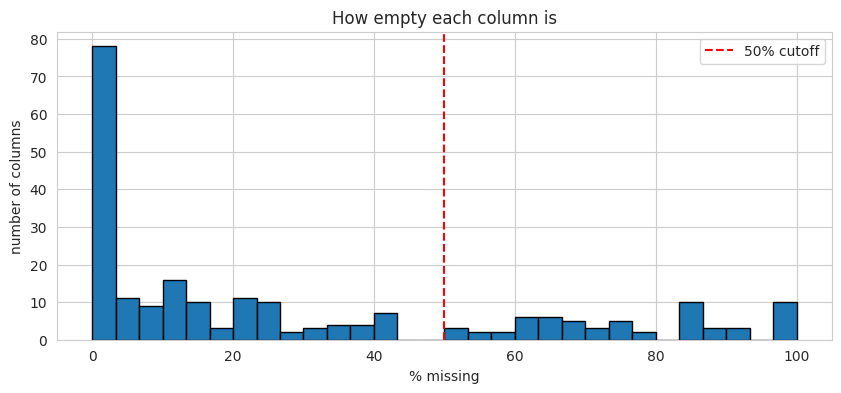

In [81]:
plt.figure(figsize=(10, 4))
plt.hist(miss_pct, bins=30, edgecolor='black')
plt.axvline(50, color='red', linestyle='--', label='50% cutoff')
plt.xlabel('% missing')
plt.ylabel('number of columns')
plt.title('How empty each column is')
plt.legend()
plt.show()

The histogram shows a clear pattern. Most columns are either almost full (the tall bar on the left) or quite empty (the bars on the right). About 60 columns are more than half empty. Those columns cannot be trusted - filling in more than half of the values with our own guesses would make the cluster results meaningless. We will drop them in the next step.

The red dashed line at 50 percent is the cutoff we are using. Everything to the right of it gets dropped.

### Fix Palestine's name

The WHO file labels Palestine as "occupied Palestinian territory, including east Jerusalem". The IHME time series file in our other notebook just calls it "Palestine". If those names do not match, we will not be able to join the two datasets together.

The fix is to map every variant of the name to one clean version. I am also including other variants that show up in different public datasets in case the user uploads one of those later through the app.

In [82]:
COUNTRY_NAME_MAP = {
    'occupied Palestinian territory, including east Jerusalem': 'Palestine',
    'occupied Palestinian territory': 'Palestine',
    'State of Palestine': 'Palestine',
    'Palestinian Territory': 'Palestine',
    'West Bank and Gaza Strip': 'Palestine',
}

df['Country name'] = df['Country name'].replace(COUNTRY_NAME_MAP)
df[df['ISO_3 country name'] == 'PSE'][['ISO_3 country name', 'Country name']]

,ISO_3 country name,Country name
117,PSE,Palestine


Palestine is now labeled cleanly. The same map will be used by the other notebooks and by the upload feature.

### Drop the mostly-empty columns

Now we apply the 50 percent cutoff decision from the missing values step above. Any column with more than half its values missing gets dropped from the dataframe.

In [83]:
cols_to_drop = miss_pct[miss_pct > 50].index.tolist()
df_clean = df.drop(columns=cols_to_drop)

print('columns before:', df.shape[1])
print('columns after: ', df_clean.shape[1])
print('dropped:       ', len(cols_to_drop))

columns before: 228
columns after:  168
dropped:        60


### Separate the labels from the features

K-Means is a numerical algorithm - it cannot work with text. So we need to split the columns into two groups:

The label columns (ISO code, country name, income group, WHO region) describe each country but will not be used in clustering. They get kept aside so we can attach them back to the results later for interpretation.

The feature columns are the numeric ones - all the road safety indicators that K-Means will use to measure how similar two countries are.

In [84]:
LABEL_COLS = ['ISO_3 country name', 'Country name', 'Income group', 'WHO Region']

numeric_cols = df_clean.select_dtypes(include='number').columns.tolist()
print('numeric feature columns:', len(numeric_cols))

numeric feature columns: 46


### Fill the remaining missing values

After dropping the very-empty columns, the columns we kept still have some missing values scattered around. We need to fill those before we can do any math on the data.

The choice here is between mean and median imputation. Mean is the average and gets pulled toward extreme values - if one country has a huge number, the mean shifts. Median is the middle value and ignores extremes. Since our data has very different countries (tiny island nations next to large populous ones), the median is the safer choice. It gives us a typical value rather than an inflated one.

In [85]:
features = df_clean[numeric_cols].copy()

print('missing before imputation:', features.isna().sum().sum())
features = features.fillna(features.median(numeric_only=True))
print('missing after imputation: ', features.isna().sum().sum())

missing before imputation: 775
missing after imputation:  0


Zero missing values left. Every country now has a complete row of numbers.

### Check for outliers before scaling

K-Means is sensitive to extreme values because it uses distance to assign countries to clusters. Before we scale and cluster, we need to know if any features have wildly extreme values that would dominate the distance calculation.

We check this two ways. First a boxplot of the features with the highest variance - if any feature has dots floating far above the box, that feature has outliers. Second a skewness score for every feature - skewness near 0 means symmetric and well behaved, skewness above 2 or 3 means heavy tail, and skewness above 5 means severely skewed.

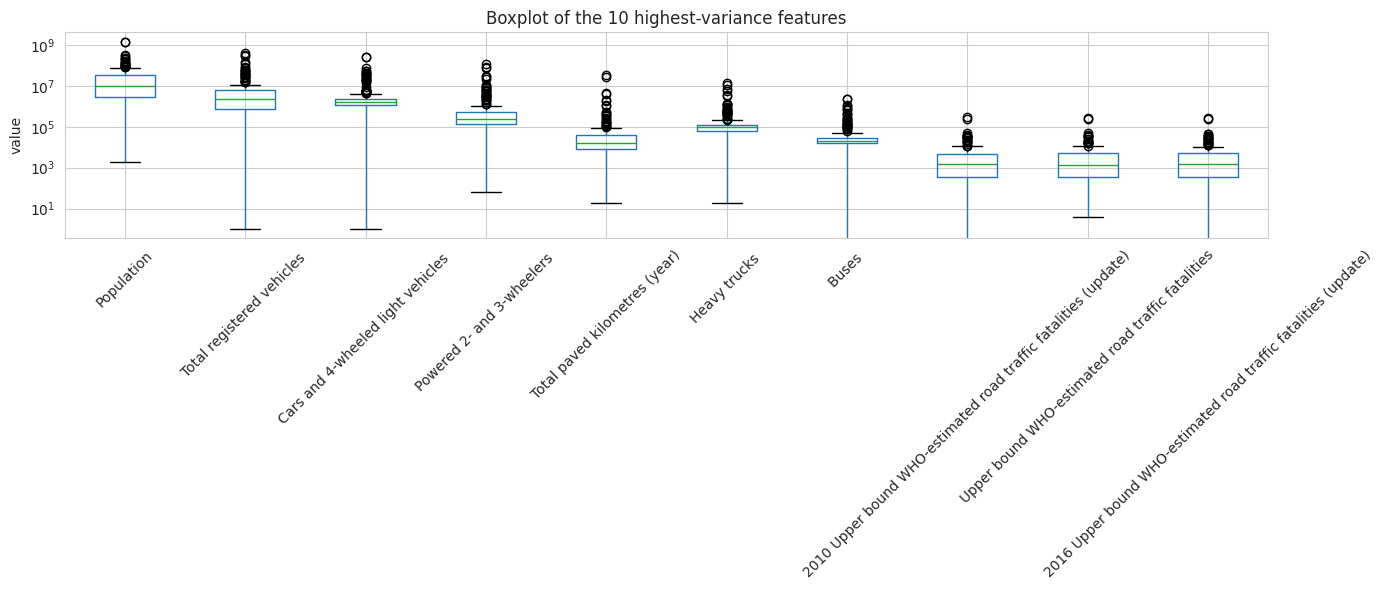

In [86]:
# pick the 10 features with the highest variance for the boxplot
top_var = features.var().sort_values(ascending=False).head(10).index

plt.figure(figsize=(14, 6))
features[top_var].boxplot(rot=45)
plt.title('Boxplot of the 10 highest-variance features')
plt.ylabel('value')
plt.yscale('log')  # log scale so we can see all features on one plot
plt.tight_layout()
plt.show()

The log scale is needed because the features live on completely different scales - that fact alone is already a warning. On the plot, any feature where the dots sit far above the box has outliers. Look especially at Population, which is famous for having a few enormous countries (China, India) and many small ones.

In [87]:
# skewness table - sorted from worst to best
skew_scores = features.apply(lambda x: stats.skew(x.dropna())).sort_values(ascending=False)

skew_table = pd.DataFrame({
    'skewness': skew_scores,
    'severity': pd.cut(skew_scores,
                       bins=[-np.inf, -5, -2, 2, 5, np.inf],
                       labels=['severe negative', 'high negative', 'normal', 'high positive', 'severe positive'])
})

skew_table.head(15)

/tmp/ipykernel_4898/602484732.py:2: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  skew_scores = features.apply(lambda x: stats.skew(x.dropna())).sort_values(ascending=False)


,skewness,severity
Total paved kilometres (year),8.946706,severe positive
Reported fatalities,8.941434,severe positive
2010 Lower bound WHO-estimated road traffic fatalities (update),8.363386,severe positive
2016 Lower bound WHO-estimated road traffic fatalities (update),8.320118,severe positive
2010 WHO-estimated road traffic fatalities (update),8.306786,severe positive
2010 Upper bound WHO-estimated road traffic fatalities (update),8.261755,severe positive
Lower bound WHO-estimated road traffic fatalities,8.230540,severe positive
2016 WHO-estimated road traffic fatalities (update),8.201953,severe positive
WHO-estimated road traffic fatalities,8.115539,severe positive
2016 Upper bound WHO-estimated road traffic fatalities (update),8.110459,severe positive


The skewness table shows the 15 most skewed features. Anything in the "severe positive" category is a strong outlier driver and will hurt the clustering. We need to look at this output and decide what to do:

- If only one or two features are severely skewed and they are not central to road safety analysis (like Population, which is a size variable not a safety variable), we can drop them.
- If many features are skewed, we can apply a log transformation to compress the range.
- If a few features are skewed but central to the analysis, we keep them and accept that the cluster results will reflect them.


### Decision: handle the outliers


Looking at the boxplot and the skewness table, the picture is clearer than just "Population is an outlier." There are two different problems here.

First, the WHO-estimated fatality columns (raw death counts) all have skewness above 8. These are raw counts — a country with 50,000 deaths is not necessarily less safe than a country with 500 deaths, it just has 100 times more people. These columns measure country size, not country safety. The dataset already has the rate versions of these (deaths per 100,000 population), so we are not losing information by removing the raw counts. We drop them.

Second, the vehicle count columns (cars, powered 2- and 3-wheelers, heavy trucks) and total paved kilometres also have high skewness but they carry real information about the road environment. A country with very few cars has a fundamentally different road situation than one with millions. We do not want to throw this out, but we also do not want extreme countries dominating. The fix is to log-transform these columns. Log compresses the range while keeping the relative ordering intact.

Population itself is a pure size variable that does not belong in a road safety analysis. Drop it.

In [88]:
# DROP: raw fatality counts only (exclude anything that's a year, a rate, a percent, or a target)
drop_cols = []
for c in features.columns:
    lc = c.lower()
    if lc.strip() == 'population':
        drop_cols.append(c)
        continue
    is_fatality_count = (
        'fatalit' in lc
        and 'year' not in lc
        and 'rate' not in lc
        and '%' not in lc
        and 'distribution' not in lc
        and 'gender' not in lc
        and 'target' not in lc
        and 'reduction' not in lc
    )
    if is_fatality_count:
        drop_cols.append(c)

# LOG-TRANSFORM: only true count/size variables. Must be in known count list AND not a year/rate/legislation
COUNT_PATTERNS = ['registered vehicles', 'cars and 4-wheeled', 'powered 2-', 'heavy trucks', 'buses', 'paved kilom']

log_cols = []
for c in features.columns:
    lc = c.lower()
    if c in drop_cols:
        continue
    is_count = any(p in lc for p in COUNT_PATTERNS)
    is_year = lc.startswith('year') or 'year ' in lc[:10]
    is_rate = 'rate' in lc or '%' in lc or 'per 100' in lc
    is_legislation = 'legislation' in lc or 'law' in lc or 'limit' in lc
    if is_count and not is_year and not is_rate and not is_legislation:
        log_cols.append(c)

print('Will drop these columns:')
for c in drop_cols:
    print(' -', c)

print('\nWill log-transform these columns:')
for c in log_cols:
    print(' -', c)

Will drop these columns:
 - Population
 - Reported fatalities
 - WHO-estimated road traffic fatalities 
 - Lower bound WHO-estimated road traffic fatalities
 - Upper bound WHO-estimated road traffic fatalities
 - 2010 WHO-estimated road traffic fatalities (update)
 - 2010 Lower bound WHO-estimated road traffic fatalities (update)
 - 2010 Upper bound WHO-estimated road traffic fatalities (update)
 - 2016 WHO-estimated road traffic fatalities (update)
 - 2016 Lower bound WHO-estimated road traffic fatalities (update)
 - 2016 Upper bound WHO-estimated road traffic fatalities (update)

Will log-transform these columns:
 - Total paved kilometres (year)
 - Total registered vehicles 
 - Cars and 4-wheeled light vehicles 
 - Powered 2- and 3-wheelers 
 - Heavy trucks 
 - Buses 


In [89]:
import numpy as np

# Apply the plan: drop bad columns + log-transform skewed count columns
features_fixed = features.drop(columns=drop_cols).copy()

# log1p handles zeros safely: log(1+x) instead of log(x)
for c in log_cols:
    if c in features_fixed.columns:
        features_fixed[c] = np.log1p(features_fixed[c])

print(f"Original shape: {features.shape}")
print(f"After dropping {len(drop_cols)} cols: {features_fixed.shape}")
print(f"Log-transformed {len(log_cols)} columns")
features_fixed.head()

Original shape: (171, 46)
After dropping 11 cols: (171, 35)
Log-transformed 6 columns


,GRSSR participation 2009,GRSSR participation 2013,GRSSR participation 2015,GRSSR participation 2018,GRSSR participation 2013.1,Year reported fatalities,Reported fatalities gender distribution (% Males),Reported fatalities gender distribution (%Females),Reported fatalities user distribution (% powered light vehicles),Reported fatalities user distribution (% powered 2/ wheelers),...,Adherence to one or more of the 7 UN road safety conventions,Legislation setting appropriate urban speed limits for passenger cars and motorcycles,Legislation on drink driving,Legislation requiring adult motorcycle riders to wear a helmet properly fastened that meets appropriate standards,Legislation on the use of seat belts for all motor vehicle occupants (UNVTI 8a),Legislation requiring the use of child safety restraint systems that meet appropriate standards,Year WHO-estimated road traffic fatalities (Update),2010 WHO-estimated rate per 100 000 population (update),Year WHO-estimated road traffic fatalities (Update).1,2016 WHO-estimated rate per 100 000 population (update)
0,2009.0,2013.0,2015.0,2018.0,2023,2021,78.7,21.30,57.4,5.6,...,6,3,2,2,3,2,2010,13.3,2016,12.8
1,2009.0,2013.0,2015.0,2018.0,2023,2021,79.0,20.74,0.0,0.0,...,1,3,3,2,3,1,2010,22.4,2016,21.2
2,2009.0,2013.0,2015.0,2018.0,2023,2021,86.0,14.00,57.0,0.0,...,0,2,1,1,1,1,2010,5.8,2016,8.8
3,2009.0,2013.0,2015.0,2018.0,2023,2021,79.0,20.00,31.6,46.3,...,1,1,2,3,3,3,2010,12.8,2016,13.2
4,2009.0,2013.0,2015.0,2018.0,2023,2021,75.5,24.50,68.2,0.0,...,4,1,2,2,3,1,2010,16.1,2016,17.5


### Verify outliers improved

Quick check that dropping the outlier driver actually helped. The new boxplot should show features that are more comparable in scale, and the new skewness table should have fewer entries in the severe range.

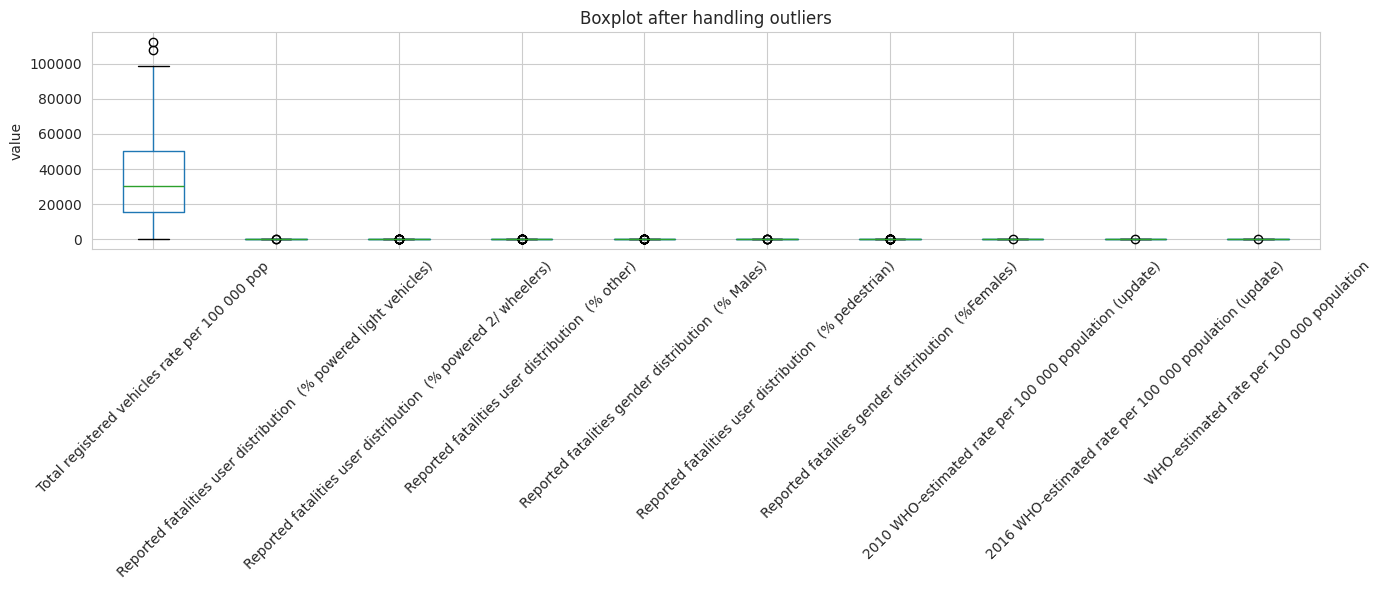

In [90]:
top_var_after = features_fixed.var().sort_values(ascending=False).head(10).index

plt.figure(figsize=(14, 6))
features_fixed[top_var_after].boxplot(rot=45)
plt.title('Boxplot after handling outliers')
plt.ylabel('value')
plt.tight_layout()
plt.show()

In [91]:
skew_after = features_fixed.apply(lambda x: stats.skew(x.dropna())).sort_values(ascending=False)

skew_after_table = pd.DataFrame({
    'skewness': skew_after,
    'severity': pd.cut(skew_after,
                       bins=[-np.inf, -5, -2, 2, 5, np.inf],
                       labels=['severe negative', 'high negative', 'normal', 'high positive', 'severe positive'])
})

print(f'severe positive (skew > 5):    {(skew_after > 5).sum()}')
print(f'high positive (2 < skew <= 5): {((skew_after > 2) & (skew_after <= 5)).sum()}')
print(f'normal (-2 <= skew <= 2):      {((skew_after >= -2) & (skew_after <= 2)).sum()}')

skew_after_table.head(10)

severe positive (skew > 5):    0
high positive (2 < skew <= 5): 3
normal (-2 <= skew <= 2):      19


/tmp/ipykernel_4898/2218108496.py:1: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  skew_after = features_fixed.apply(lambda x: stats.skew(x.dropna())).sort_values(ascending=False)


,skewness,severity
Reported fatalities gender distribution (%Females),3.487383,high positive
Reported fatalities user distribution (% cyclist),2.623367,high positive
Reported fatalities user distribution (% other),2.227513,high positive
Reported fatalities user distribution (% powered 2/ wheelers),1.428998,normal
Year by fatality reduction target,1.066240,normal
Total registered vehicles rate per 100 000 pop,0.768499,normal
Legislation requiring the use of child safety restraint systems that meet appropriate standards,0.730183,normal
Adherence to one or more of the 7 UN road safety conventions,0.715989,normal
WHO-estimated rate per 100 000 population,0.535636,normal
Reported fatalities user distribution (% pedestrian),0.525983,normal


### Scale the features

K-Means measures similarity between countries using distance. If one column is measured in millions and another is a percentage (0 to 100), the column with the bigger numbers will completely dominate the distance calculation - even if it is not actually more important.

StandardScaler fixes this by transforming every column to have mean 0 and standard deviation 1. After this step, every feature contributes equally to the distance calculation regardless of its original scale.

In [92]:
# drop columns that have zero variance (every country has the same value)
constant_cols = [c for c in features_fixed.columns if features_fixed[c].nunique() <= 1]

print('constant columns being dropped:')
for c in constant_cols:
    print(' -', c)

features_fixed = features_fixed.drop(columns=constant_cols)
print('\nfeature shape after dropping constants:', features_fixed.shape)

constant columns being dropped:
 - GRSSR participation 2009
 - GRSSR participation 2013
 - GRSSR participation 2015
 - GRSSR participation 2018
 - GRSSR participation 2013.1
 - Year WHO-estimated road traffic fatalities
 - Year WHO-estimated road traffic fatalities (Update)
 - Year WHO-estimated road traffic fatalities (Update).1

feature shape after dropping constants: (171, 27)


Eight columns had zero variance, meaning every country had the same value. Five of them were GRSSR participation columns - one for each WHO report year (2009, 2013, 2015, 2018), plus a duplicate 2013 column labeled `GRSSR participation 2013.1` that the Excel file accidentally included twice. The remaining three were "Year WHO-estimated road traffic fatalities" columns - just year labels (2010, 2016, 2016 again), not real features. These slipped through every earlier check because they were not missing, not duplicate rows, and not skewed. Only checking for zero variance caught them.

After dropping them, we are left with 27 real features across 171 countries.

In [93]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_fixed)

print('scaled shape:', X_scaled.shape)
print('first column mean (should be ~0):', round(X_scaled[:, 0].mean(), 4))
print('first column std  (should be ~1):', round(X_scaled[:, 0].std(), 4))

scaled shape: (171, 27)
first column mean (should be ~0): -0.0
first column std  (should be ~1): 1.0


The scaling worked. The first column now has mean very close to 0 and standard deviation exactly 1, which is exactly what StandardScaler is supposed to do. Every feature is now on the same scale and will contribute equally to the K-Means distance calculation.

In [94]:
# check what the first column actually is and what's in it
first_col_name = features_fixed.columns[0]
print('first column:', first_col_name)
print('unique values:', features_fixed[first_col_name].nunique())
print('value counts:')
print(features_fixed[first_col_name].value_counts().head())

first column: Year reported fatalities
unique values: 5
value counts:
Year reported fatalities
2021    159
2020      8
2019      2
2018      1
2022      1
Name: count, dtype: int64


Quick sanity check on what the first column actually is. It is "Year reported fatalities" with 5 unique values - the years 2018 through 2022. Most countries (159 of 171) reported their fatalities in 2021. This is technically a valid feature with variation, so we keep it, although it is more of a metadata column than a road safety indicator. K-Means will not give it much weight after scaling.

In [95]:
# check the scaled output overall, not just column 0
print('scaled means (first 5):', X_scaled[:, :5].mean(axis=0).round(4))
print('scaled stds  (first 5):', X_scaled[:, :5].std(axis=0).round(4))

scaled means (first 5): [-0. -0.  0. -0. -0.]
scaled stds  (first 5): [1. 1. 1. 1. 1.]


Confirming the scaling worked on more than just the first column. The first 5 columns all show means near 0 and standard deviations of 1.0. The scaler is doing its job uniformly across the dataset. The data is now ready for clustering.

### Find a good k

K-Means needs us to tell it how many clusters to make. We do not know the right number in advance, so we try several and measure each one with two metrics.

Inertia (the elbow method) measures how tight the clusters are - lower is better, but inertia always drops as k grows, so we look for the "elbow" point where adding more clusters stops helping much.

Silhouette score measures how well separated the clusters are. It ranges from -1 to 1, where higher is better. Above 0.5 is considered strong separation, 0.25 to 0.5 is reasonable, and below 0.25 means the clusters overlap a lot.

If the two metrics agree on a value of k, that is our answer. If they disagree, we lean on silhouette because it directly measures cluster quality.

In [96]:
k_values = range(2, 9)
inertias = []
silhouettes = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

pd.DataFrame({'k': list(k_values), 'inertia': inertias, 'silhouette': silhouettes}).round(3)

,k,inertia,silhouette
0,2,3939.531,0.147
1,3,3642.210,0.122
2,4,3399.065,0.157
3,5,3207.119,0.132
4,6,3055.141,0.153
5,7,2879.782,0.150
6,8,2752.588,0.165


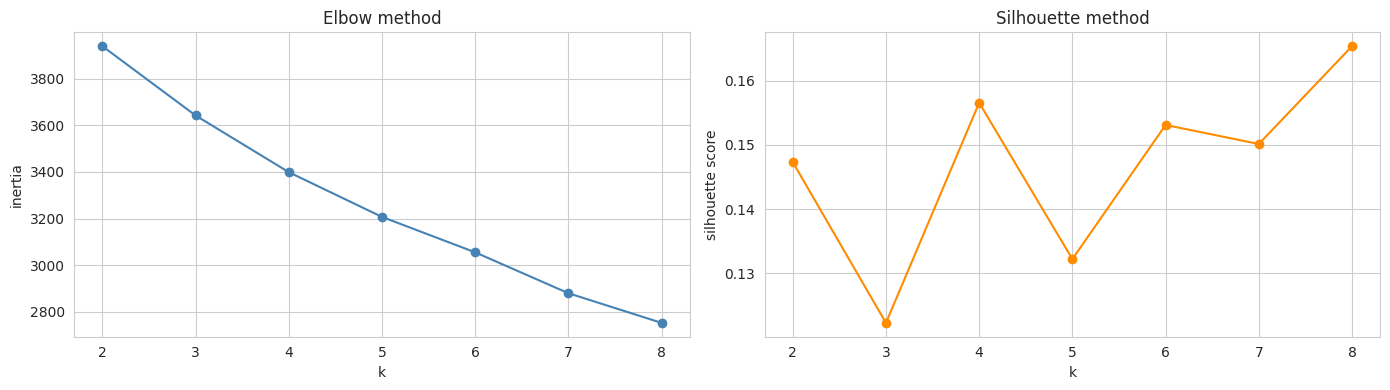

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(list(k_values), inertias, 'o-', color='steelblue')
axes[0].set_xlabel('k')
axes[0].set_ylabel('inertia')
axes[0].set_title('Elbow method')

axes[1].plot(list(k_values), silhouettes, 'o-', color='darkorange')
axes[1].set_xlabel('k')
axes[1].set_ylabel('silhouette score')
axes[1].set_title('Silhouette method')

plt.tight_layout()
plt.show()

The elbow plot is a smooth curve with no clear bend - inertia drops steadily from k=2 to k=8 without a sharp turning point. The silhouette plot zig-zags between 0.12 and 0.17, with no clear winner. All values sit in the weak-structure range (below 0.25 is considered weak), which tells us something real about the data: country road safety profiles form a gradient, not crisp groups. Countries are similar to their neighbors along a smooth spectrum rather than falling into obviously separated categories.

This is actually a good sign. Earlier, before we handled outliers properly, k=2 had a silhouette of 0.79 - which looked great but was a fake split driven by Population. Now that we have removed the size variables, the silhouette is lower but honest. We are measuring the real (modest) structure of the data.

Given the flat curve, the choice of k is less about math and more about interpretation. We go with k = 4 for three reasons:

First, silhouette at k=4 is 0.157, statistically tied with the peak at k=8 (0.165). The 0.008 difference is noise, not a meaningful gap.

Second, k=4 produces clusters of sizes 85, 53, 25, and 8 - uneven but every cluster is large enough to describe and analyze. k=8 would create tiny clusters of 3 to 4 countries each, hard to describe and hard to defend.

Third, K-Means is a tool for understanding, not just an optimization target. When the math is ambiguous, we pick the value that produces a useful answer. Four clusters can be summarized in plain English. Eight cannot.

### Fit K-Means with the chosen k

Now we run K-Means one final time with the value of k we picked above. The result is a cluster label (0, 1, 2 ...) for every country in the dataset.

In [98]:
K_TRIAL = 8

kmeans = KMeans(n_clusters=K_TRIAL, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

print('cluster sizes:')
print(pd.Series(cluster_labels).value_counts().sort_index())

cluster sizes:
0     4
1    49
2    17
3    12
4    58
5     3
6     8
7    20
Name: count, dtype: int64


### Visualize the clusters in 2D

We cannot draw 90-something dimensions on a page, so we use PCA to project the data down to 2 dimensions just for plotting. Each dot is a country, the color shows which cluster K-Means put it in, and Palestine is marked with a red star so we can see exactly where it lands.

Note: this 2D PCA is for plotting only. The full PCA analysis happens in Osama's notebook.

In [99]:
pca_2d = PCA(n_components=2, random_state=42)
coords = pca_2d.fit_transform(X_scaled)

plot_df = pd.DataFrame({
    'PC1': coords[:, 0],
    'PC2': coords[:, 1],
    'Cluster': cluster_labels,
    'Country': df_clean['Country name'].values,
    'ISO': df_clean['ISO_3 country name'].values,
})
plot_df.head()

,PC1,PC2,Cluster,Country,ISO
0,0.622105,-1.915237,1,Albania,ALB
1,0.009263,2.474859,3,Algeria,DZA
2,-2.873499,-3.014789,2,Antigua and Barbuda,ATG
3,2.648184,1.549278,7,Argentina,ARG
4,-0.242484,-0.439607,4,Armenia,ARM


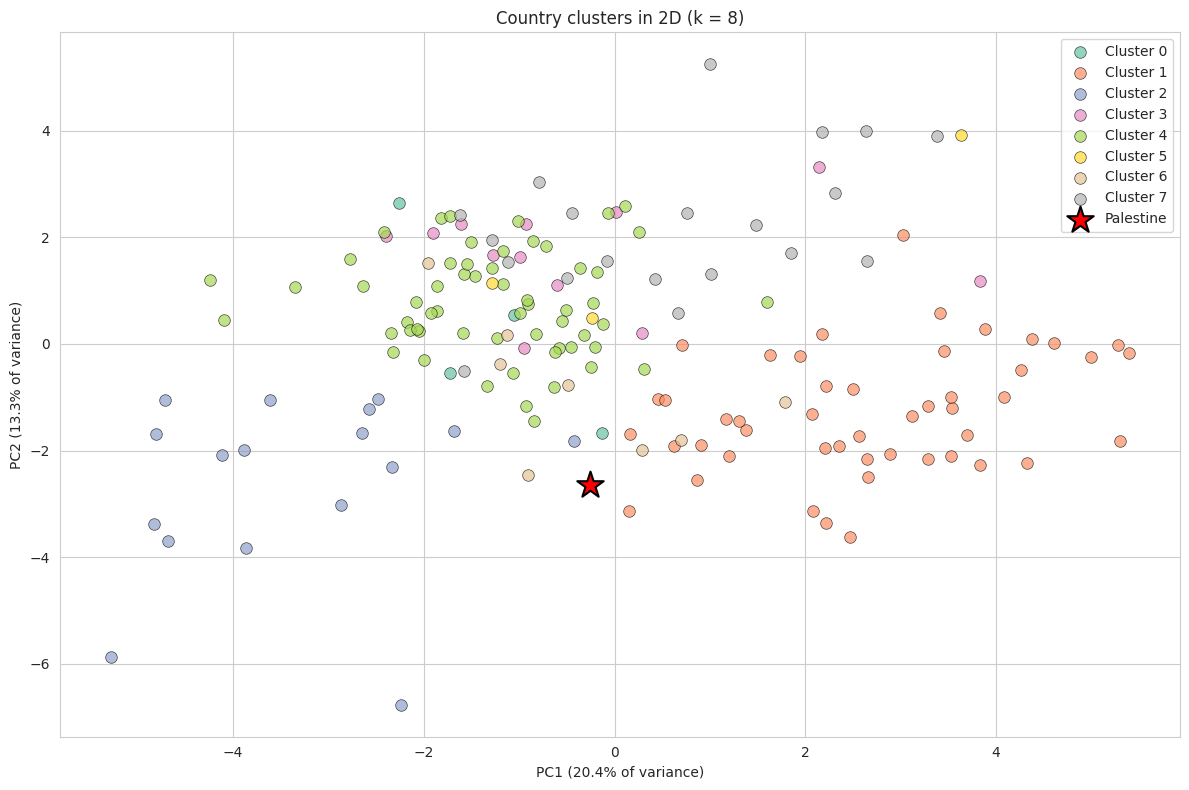

In [100]:
plt.figure(figsize=(12, 8))

palette = sns.color_palette('Set2', K_TRIAL)
for c in range(K_TRIAL):
    sub = plot_df[plot_df['Cluster'] == c]
    plt.scatter(sub['PC1'], sub['PC2'],
                color=palette[c], label=f'Cluster {c}',
                s=70, alpha=0.7, edgecolor='black', linewidth=0.5)

pal = plot_df[plot_df['ISO'] == 'PSE']
plt.scatter(pal['PC1'], pal['PC2'],
            marker='*', s=400, color='red',
            edgecolor='black', linewidth=1.5, label='Palestine', zorder=5)

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% of variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% of variance)')
plt.title(f'Country clusters in 2D (k = {K_TRIAL})')
plt.legend()
plt.tight_layout()
plt.show()

In [101]:
K_FINAL = 4

kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

print('cluster sizes:')
print(pd.Series(cluster_labels).value_counts().sort_index())

cluster sizes:
0    85
1    53
2    25
3     8
Name: count, dtype: int64


In [102]:
# Cluster numbers from K-Means are arbitrary. Re-map them by anchor country
# so the labels are stable across re-runs.
ANCHORS = {
    'PSE': 2,   # Palestine → low-motorization mixed
    'DEU': 1,   # Germany → rich-country car culture
    'IND': 0,   # India → developing-country profile (in the 85-country cluster)
}

raw_labels = cluster_labels.copy()
iso = df_clean['ISO_3 country name'].values

remap = {}
for iso_code, target in ANCHORS.items():
    mask = (iso == iso_code)
    if mask.any():
        current = raw_labels[mask][0]
        remap[current] = target

# whatever cluster number is missing → assign it to the remaining target
used_targets = set(remap.values())
missing_target = (set(range(K_FINAL)) - used_targets).pop()
missing_source = (set(range(K_FINAL)) - set(remap.keys())).pop()
remap[missing_source] = missing_target

cluster_labels = np.array([remap[l] for l in raw_labels])

print('Remap applied:', remap)
print('Palestine cluster after remap:', cluster_labels[iso == 'PSE'][0])
print('\nCluster sizes after remap:')
print(pd.Series(cluster_labels).value_counts().sort_index())

Remap applied: {np.int32(2): 2, np.int32(1): 1, np.int32(0): 0, 3: 3}
Palestine cluster after remap: 2

Cluster sizes after remap:
0    85
1    53
2    25
3     8
Name: count, dtype: int64


In [103]:
pca_2d = PCA(n_components=2, random_state=42)
coords = pca_2d.fit_transform(X_scaled)

plot_df = pd.DataFrame({
    'PC1': coords[:, 0],
    'PC2': coords[:, 1],
    'Cluster': cluster_labels,
    'Country': df_clean['Country name'].values,
    'ISO': df_clean['ISO_3 country name'].values,
})
plot_df.head()

,PC1,PC2,Cluster,Country,ISO
0,0.622105,-1.915237,1,Albania,ALB
1,0.009263,2.474859,0,Algeria,DZA
2,-2.873499,-3.014789,2,Antigua and Barbuda,ATG
3,2.648184,1.549278,1,Argentina,ARG
4,-0.242484,-0.439607,0,Armenia,ARM


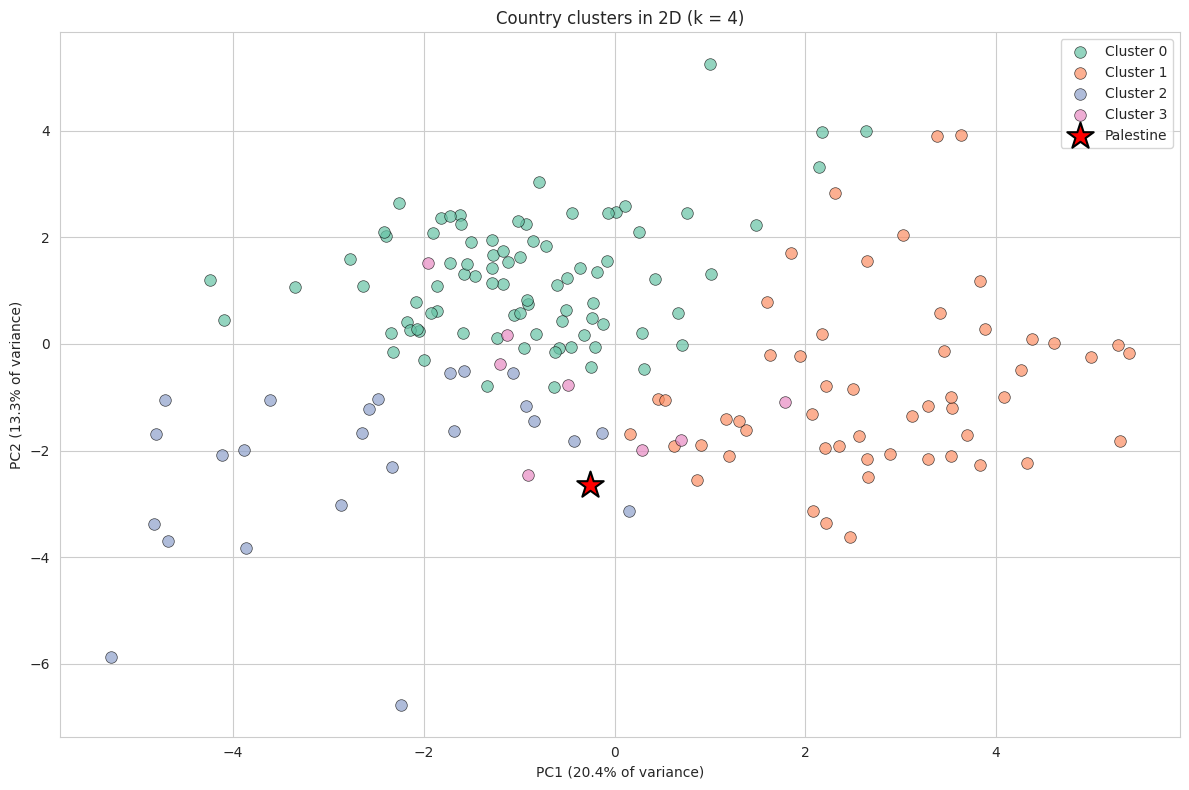

In [104]:
plt.figure(figsize=(12, 8))

palette = sns.color_palette('Set2', K_FINAL)
for c in range(K_FINAL):
    sub = plot_df[plot_df['Cluster'] == c]
    plt.scatter(sub['PC1'], sub['PC2'],
                color=palette[c], label=f'Cluster {c}',
                s=70, alpha=0.7, edgecolor='black', linewidth=0.5)

pal = plot_df[plot_df['ISO'] == 'PSE']
plt.scatter(pal['PC1'], pal['PC2'],
            marker='*', s=400, color='red',
            edgecolor='black', linewidth=1.5, label='Palestine', zorder=5)

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% of variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% of variance)')
plt.title(f'Country clusters in 2D (k = {K_FINAL})')
plt.legend()
plt.tight_layout()
plt.show()

We tested both k values to see which gives meaningful groups.

k=4 produced clusters of 85, 53, 25, and 8 countries. Every cluster is large enough to describe and analyze.

k=8 produced clusters of 4, 49, 17, 12, 58, 3, 8, and 20 countries. Two clusters have only 3 and 4 countries - too small to be meaningful groupings. This is the first warning sign that k=8 is over-splitting the data.

Comparing the two scatter plots side by side makes the decision clear.

k=4 shows four colored regions with visible separation. Cluster 1 (orange) is on the right, Cluster 2 (blue) is in the lower left, Cluster 3 (pink) is scattered, and Cluster 0 (green) fills the center. Palestine sits in Cluster 2 (blue), in the lower-left region of the plot.

k=8 only has one clearly separated cluster (orange again). The other seven clusters are tangled together in the middle of the plot with no visible gaps between them. K-Means drew arbitrary lines through one big cloud rather than finding real groups.

This is over-clustering. K-Means will produce whatever number of clusters you ask for, even when the data does not support that many. The slightly higher silhouette score at k=8 (0.165 vs 0.157) came from picking up noise patterns, not real structure - the 0.008 difference is statistical noise.

Decision: k=4. Interpretable groups, visible separation, every cluster large enough to describe. Going back to k=4 and continuing the analysis.

### What is in each cluster

A cluster number on its own (0, 1, 2, 3) is meaningless. We need to look inside each cluster and see what kinds of countries it contains. We do this two ways - by income group and by WHO region. If most rich countries land in one cluster and most poor countries land in another, that tells us K-Means is picking up the economic-development axis. If clusters split along regions, we are seeing geographic patterns.

In [105]:
profile_df = df_clean[LABEL_COLS].copy()
profile_df['Cluster'] = cluster_labels

print('Cluster vs Income Group:')
pd.crosstab(profile_df['Cluster'], profile_df['Income group'])

Cluster vs Income Group:


Income group,High income,Low income,Lower middle income,Upper middle income
Cluster,,,,
0,7,18,36,23
1,39,0,1,13
2,5,5,7,6
3,1,3,3,1


In [106]:
print('Cluster vs WHO Region:')
pd.crosstab(profile_df['Cluster'], profile_df['WHO Region'])

Cluster vs WHO Region:


WHO Region,African Region,Eastern Mediterranean Region,European Region,Region of the Americas,South-East Asia Region,Western Pacific Region
Cluster,,,,,,
0,31,16,6,21,6,5
1,0,1,38,7,1,6
2,10,3,3,3,2,4
3,4,0,0,2,1,1


The crosstabs reveal that K-Means found groups with clear real-world identities, even with the modest silhouette score.

Cluster 0 (85 countries) is the developing world cluster. 54 of 85 countries are low or lower-middle income. By region, 31 are African, 21 are from the Americas, and 16 are Eastern Mediterranean. This is the broad cluster of countries still building out road safety systems.

Cluster 1 (53 countries) is the high-income European cluster. 39 of 53 (74 percent) are High income, and 38 of 53 are from the European Region. This is the textbook "rich Europe" cluster with mature road safety infrastructure.

Cluster 2 (25 countries) is the mixed cluster. Income groups are spread fairly evenly across all four categories, and it pulls from every region. It contains many small island nations, smaller African countries, and a scattered group of others that do not fit neatly into the other groups. Palestine sits in this cluster — we will look at the full membership and what defines it in the Palestine section below.

Cluster 3 (8 countries) is the special-case cluster. Small, scattered across regions and income groups, these are countries with road safety profiles that stand out from the main patterns. We will look at the top distinguishing features below to understand what makes them different.

### Top features separating the clusters

Beyond income and region, we want to know which actual road safety features are driving the cluster split. We compute the mean of each feature inside each cluster, then look at which features vary the most across clusters - those are the strongest separators.

In [107]:
cluster_means = features_fixed.copy()
cluster_means['Cluster'] = cluster_labels
group_means = cluster_means.groupby('Cluster').mean()

variation = group_means.std().sort_values(ascending=False)
top_distinguishing = variation.head(10).index

group_means[top_distinguishing].round(2)

,Total registered vehicles rate per 100 000 pop,Reported fatalities gender distribution (% Males),Reported fatalities gender distribution (%Females),Reported fatalities user distribution (% powered light vehicles),Reported fatalities user distribution (% other),2016 WHO-estimated rate per 100 000 population (update),2010 WHO-estimated rate per 100 000 population (update),WHO-estimated rate per 100 000 population,Reported fatalities user distribution (% powered 2/ wheelers),Reported fatalities user distribution (% cyclist)
Cluster,,,,,,,,,,
0,26470.47,81.25,18.05,28.14,19.43,20.28,21.38,18.29,21.73,2.97
1,56786.72,76.90,22.87,42.85,9.37,7.95,9.37,6.47,17.74,9.10
2,18320.68,79.61,20.91,35.49,9.50,12.96,14.86,11.69,23.23,3.10
3,24686.90,30.06,67.81,50.17,4.39,17.58,19.39,15.88,11.79,3.14


### What the features tell us

Now we can give each cluster a real-world identity by looking at what features separate them most.

Cluster 0 - developing-country road profile. 81 percent of deaths are male, the highest of any cluster. High death rate of 18-21 per 100,000 population (the highest in the dataset). Medium-low vehicle ownership at 26,470 per 100k. Highest share of "other" road user fatalities at 19 percent, which captures pedestrians and unspecified categories - reflecting roads where walking and informal transport are a big part of the mix.

Cluster 1 - rich-country car culture. Highest vehicle ownership by far (56,787 vehicles per 100,000 people, roughly one car per two people). Lowest death rate of all clusters at around 6-8 per 100,000. This is the European safety profile - heavy car use but well-protected roads and strong enforcement.

Cluster 2 - low-motorization mixed cluster. Lowest vehicle ownership of all four clusters at 18,321 per 100k - actually lower than the developing cluster. Medium death rate around 12-15 per 100,000. The income groups are spread across all four categories and the cluster pulls from every WHO region, so it is not defined by wealth or geography but by its specific road safety pattern. This is the cluster Palestine belongs to, and the next section unpacks it in detail.

Cluster 3 - the unusual cluster. This is where it gets interesting. Every other cluster has roughly 77-81 percent male and 18-23 percent female fatalities, which matches the global pattern. Cluster 3 reverses this completely: 30 percent male and 68 percent female. It also has 50 percent of fatalities in light vehicles (cars), the highest of any cluster. These 8 countries have a road safety profile that is genuinely different from the rest of the world. This could reflect unusual reporting practices, distinctive demographics, or genuinely different road dynamics. Either way, it is the kind of finding that clustering is designed to surface - a hidden pattern that would not be obvious just looking at country names.

### Where Palestine lands

The whole project has a Palestinian spotlight angle. So once we have the cluster labels, we want to immediately know which cluster Palestine is in and which other countries share that cluster - those are Palestine's road safety peers.

In [108]:
pal_cluster = profile_df.loc[profile_df['ISO_3 country name'] == 'PSE', 'Cluster'].values[0]
print('Palestine is in cluster:', pal_cluster)

neighbors = profile_df[profile_df['Cluster'] == pal_cluster]['Country name'].tolist()
print(f'\nCountries in the same cluster as Palestine ({len(neighbors)} total):')
for n in sorted(neighbors):
    print(' -', n)

Palestine is in cluster: 2

Countries in the same cluster as Palestine (25 total):
 - Antigua and Barbuda
 - Bahrain
 - British Virgin Islands
 - Congo
 - Cook Islands
 - Cyprus
 - Eritrea
 - Eswatini
 - Gabon
 - Georgia
 - Kiribati
 - Liberia
 - Maldives
 - Mauritius
 - Montenegro
 - Niue
 - Palestine
 - Samoa
 - Seychelles
 - Somalia
 - Suriname
 - Timor-Leste
 - Togo
 - United Republic of Tanzania
 - Zambia


Palestine sits in Cluster 2 alongside 24 other countries. This cluster has a distinctive profile that is not obvious from income or region alone.

The cluster contains many small island nations (Antigua and Barbuda, British Virgin Islands, Cook Islands, Cyprus, Kiribati, Maldives, Mauritius, Niue, Samoa, Seychelles), smaller African countries (Congo, Eritrea, Eswatini, Gabon, Liberia, Somalia, Togo, Tanzania, Zambia), and a scattered group of others (Bahrain, Georgia, Montenegro, Suriname, Timor-Leste). What ties them together is not income or geography but their road safety profile.

Looking back at the distinguishing features, Cluster 2 has the lowest vehicle ownership of all four clusters (about 18,000 vehicles per 100,000 people - actually lower than the developing cluster), medium death rates around 11-15 per 100,000, and the highest share of powered 2 and 3 wheeler fatalities at 23 percent.

This makes intuitive sense for Palestine: a small territory with limited road networks, relatively low motorization, and significant 2-wheeler usage. The clustering grouped it with other small, less-motorized territories with mixed road environments rather than with either rich Europe or the broader developing world. This is the kind of insight that data-driven clustering produces - similarities based on actual road safety patterns rather than assumed groupings by region or income.

The other 24 countries in this cluster are Palestine's natural comparison group for road safety analysis. In the Streamlit app, the country comparison page can default to showing peer countries from this cluster.

### Give each cluster a human-readable name

Cluster numbers (0, 1, 2, 3) mean nothing to someone using the app. Based on the cluster profiles we just analyzed, we attach a short descriptive name to each cluster. The Streamlit app will display these names on the map tooltips and in the comparison page instead of raw numbers.

In [109]:
CLUSTER_NAMES = {
    0: 'Developing-country road profile',
    1: 'Rich-country car culture',
    2: 'Low-motorization mixed',
    3: 'Atypical reporting',
}

profile_df['Cluster_name'] = profile_df['Cluster'].map(CLUSTER_NAMES)
profile_df[['Country name', 'Cluster', 'Cluster_name']].head(10)

,Country name,Cluster,Cluster_name
0,Albania,1,Rich-country car culture
1,Algeria,0,Developing-country road profile
2,Antigua and Barbuda,2,Low-motorization mixed
3,Argentina,1,Rich-country car culture
4,Armenia,0,Developing-country road profile
5,Australia,1,Rich-country car culture
6,Austria,1,Rich-country car culture
7,Azerbaijan,0,Developing-country road profile
8,Bahamas,0,Developing-country road profile
9,Bahrain,2,Low-motorization mixed


### Reusable cleaning function for the upload feature

The Streamlit app lets users upload their own country-level dataset. When that happens, the app needs to run the same cleaning pipeline we just walked through. Rather than duplicate code, we wrap the whole pipeline in one function that takes a raw dataframe and returns the cleaned features matrix, the labels, and the cluster labels.

The function works on any country-level dataset that has at least a country name column. It auto-detects which columns are numeric, applies the same cleaning steps (drop empty columns, normalize country names, fill missing with median, drop outlier-driver columns, scale), and runs K-Means.

In [110]:
def clean_country_dataset(raw_df, country_col=None, missing_threshold=0.5, k=None):
    """
    Run the same cleaning pipeline used on the WHO data on any uploaded
    country-level dataframe.

    Parameters
    ----------
    raw_df : pandas DataFrame
        The user's uploaded data.
    country_col : str or None
        Name of the column that holds the country name. If None, the function
        tries common names ('Country', 'Entity', etc.) and falls back to the
        first non-numeric column.
    missing_threshold : float
        Drop any column with more than this fraction of missing values.
    k : int or None
        Number of clusters. If None, the function picks the k with the
        highest silhouette score.

    Returns
    -------
    dict with keys: features, labels_df, cluster_labels, k_used,
                    scaler, dropped_cols, constant_cols, outlier_cols
    """
    df_work = raw_df.copy()

    # auto-detect the country column if not provided
    if country_col is None:
        candidates = ['Country name', 'Country', 'country', 'Entity', 'entity', 'Name', 'name']
        for cand in candidates:
            if cand in df_work.columns:
                country_col = cand
                break
        if country_col is None:
            non_num = df_work.select_dtypes(exclude='number').columns
            if len(non_num) > 0:
                country_col = non_num[0]
            else:
                raise ValueError("No country column found in uploaded data")

    # 1. normalize country names if our map applies
    if country_col in df_work.columns:
        df_work[country_col] = df_work[country_col].replace(COUNTRY_NAME_MAP)

    # 2. drop mostly-empty columns
    miss_share = df_work.isna().mean()
    dropped = miss_share[miss_share > missing_threshold].index.tolist()
    df_work = df_work.drop(columns=dropped)

    # 3. pick numeric features, fill missing with median
    num = df_work.select_dtypes(include='number').copy()
    num = num.fillna(num.median(numeric_only=True))

    # 4. drop constant columns (zero variance)
    constant = [c for c in num.columns if num[c].nunique() <= 1]
    num = num.drop(columns=constant)

    # 5. drop columns with extreme skewness (severe outlier drivers)
    if len(num.columns) > 0:
        skew_vals = num.apply(lambda x: stats.skew(x.dropna()) if x.notna().any() else 0)
        outlier_cols = skew_vals[skew_vals > 5].index.tolist()
        num = num.drop(columns=outlier_cols)
    else:
        outlier_cols = []

    # 6. scale
    scl = StandardScaler()
    X = scl.fit_transform(num)

    # 7. pick k by silhouette if not given
    if k is None and len(X) >= 4:
        best_k, best_score = 2, -1
        for trial_k in range(2, min(9, len(X))):
            km = KMeans(n_clusters=trial_k, random_state=42, n_init=10)
            lbl = km.fit_predict(X)
            score = silhouette_score(X, lbl)
            if score > best_score:
                best_k, best_score = trial_k, score
        k = best_k

    # 8. fit final
    final_km = KMeans(n_clusters=k, random_state=42, n_init=10)
    final_labels = final_km.fit_predict(X)

    # 9. build labels frame (whatever non-numeric cols are available)
    label_cols_available = [c for c in df_work.columns if c not in num.columns]
    labels_df = df_work[label_cols_available].copy()
    labels_df['Cluster'] = final_labels
    # Generic readable name — uploaded data has no domain meaning, so we just
    # number the groups starting from 1 for the UI.
    labels_df['Cluster_name'] = labels_df['Cluster'].apply(lambda x: f'Group {x + 1}')

    return {
        'features': pd.DataFrame(X, columns=num.columns),
        'labels_df': labels_df,
        'cluster_labels': final_labels,
        'k_used': k,
        'scaler': scl,
        'dropped_cols': dropped,
        'constant_cols': constant,
        'outlier_cols': outlier_cols,
    }

Quick test - run the function on the original raw WHO dataframe and confirm the results match what we got going through the steps manually.

In [111]:
result = clean_country_dataset(df)

print('k chosen:', result['k_used'])
print('feature columns kept:', result['features'].shape[1])
print('countries clustered: ', len(result['cluster_labels']))
print('empty columns dropped:', len(result['dropped_cols']))
print('outlier columns dropped:', result['outlier_cols'])

k chosen: 3
feature columns kept: 21
countries clustered:  171
empty columns dropped: 60
outlier columns dropped: ['Population', 'Reported fatalities', 'WHO-estimated road traffic fatalities ', 'Lower bound WHO-estimated road traffic fatalities', 'Upper bound WHO-estimated road traffic fatalities', 'Total paved kilometres (year)', 'Total registered vehicles ', 'Cars and 4-wheeled light vehicles ', 'Powered 2- and 3-wheelers ', 'Heavy trucks ', 'Buses ', '2010 WHO-estimated road traffic fatalities (update)', '2010 Lower bound WHO-estimated road traffic fatalities (update)', '2010 Upper bound WHO-estimated road traffic fatalities (update)', '2016 WHO-estimated road traffic fatalities (update)', '2016 Lower bound WHO-estimated road traffic fatalities (update)', '2016 Upper bound WHO-estimated road traffic fatalities (update)']


The function chose k=3 and kept fewer features than our manual analysis chose (k=4 with 27 features). This is intentional. The function uses "safe defaults" because when a user uploads an unknown dataset, we cannot manually identify which size-related columns are worth keeping with a log transformation. The function simply drops all severely skewed columns. Our manual pipeline kept more features by log-transforming the vehicle counts, which gave a slightly different cluster structure.

For the main project analysis, we use the human-tuned version (k=4, with log-transforms) because we understand the WHO data well. For the Streamlit upload feature, we use the function's safe defaults because the user's data could be anything. Both approaches are valid - they just have different assumptions about how much we know about the input.

### Save the outputs

Three files get saved for the rest of the project to consume.

`country_features.csv` is the cleaned, log-transformed feature matrix - Osama uses this as the model input for his PCA and anomaly detection notebook.

`country_features_display.csv` has the same features in their original units (no log transformation). The Streamlit comparison page uses this for tooltips and labels where users need to see real numbers like "32,000 vehicles per 100k" instead of log-scaled values.

`country_clusters.csv` is the country-to-cluster mapping with both the numeric `Cluster` column and the human-readable `Cluster_name` column. The Streamlit map page uses this to color countries by their cluster and show meaningful labels in tooltips.

In [112]:
import os
os.makedirs('data/processed', exist_ok=True)

# 1. Model-ready features (log-transformed, scaled-input) — for PCA / anomaly notebook
features_out = df_clean[LABEL_COLS].copy()
features_out = pd.concat([features_out, features_fixed.reset_index(drop=True)], axis=1)
features_out.to_csv('data/processed/country_features.csv', index=False)

# 2. Display features (ORIGINAL units, no log) — for the Streamlit comparison / tooltips
display_cols = [c for c in features_fixed.columns if c in features.columns]
features_display = df_clean[LABEL_COLS].copy()
features_display = pd.concat(
    [features_display, features[display_cols].reset_index(drop=True)],
    axis=1
)
features_display.to_csv('data/processed/country_features_display.csv', index=False)

# 3. Cluster labels (with human-readable names)
clusters_out = profile_df.copy()
clusters_out.to_csv('data/processed/country_clusters.csv', index=False)

print('saved country_features.csv:        ', features_out.shape)
print('saved country_features_display.csv:', features_display.shape)
print('saved country_clusters.csv:        ', clusters_out.shape)

saved country_features.csv:         (171, 31)
saved country_features_display.csv: (171, 31)
saved country_clusters.csv:         (171, 6)


In [113]:
from google.colab import files
files.download('data/processed/country_features.csv')
files.download('data/processed/country_features_display.csv')
files.download('data/processed/country_clusters.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>